<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h1 style="margin:0; font-size:30px;">Learning Day 15 — Notebook 1</h1>
  <h2 style="margin:8px 0 0 0; font-size:21px; font-weight:500; color:#dbeafe;">AutoML with PyCaret: Setup, Model Comparison, Evaluation, Confusion Matrix, and AUC Curve</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.58; color:#e5e7eb;">This notebook covers the Beginner MVD task using the Breast Cancer Wisconsin dataset from scikit-learn. The goal is to understand what PyCaret automates, compare classification models, select the best model by AUC, create the selected model, evaluate it, and interpret the output using clean business-style charts.</p>

  BY RUTURAJ MOKASHI
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. Notebook Scope and Learning Goals</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Topic:</b> AutoML with PyCaret.</p>
<p><b>Dataset:</b> Breast Cancer Wisconsin from <code>sklearn.datasets.load_breast_cancer()</code>.</p>
<p><b>Target:</b> <code>target</code>, where the model predicts whether a tumour case belongs to one of two diagnosis groups.</p>
<p><b>What this notebook covers:</b></p>
<ul>
  <li>What AutoML means in simple words.</li>
  <li>What PyCaret does automatically during <code>setup()</code>.</li>
  <li>How <code>compare_models()</code> benchmarks many models quickly.</li>
  <li>How to identify the best model by <b>AUC</b>.</li>
  <li>How to create and evaluate the selected model.</li>
  <li>How to read a confusion matrix and AUC curve in business language.</li>
</ul>
<p><b>Important:</b> This notebook does not install packages inside the notebook. Install PyCaret in your environment before running if it is missing.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">2. Simple Theory — What AutoML and PyCaret Mean</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>AutoML</b> means automated machine learning. In normal machine learning, we manually prepare the data, build preprocessing pipelines, train many models, tune settings, compare metrics, create plots, and save the final model. AutoML helps automate many of these repeated steps.</p>
<p><b>PyCaret</b> is a low-code AutoML library. Low-code does not mean no thinking. It means that many standard workflow steps are wrapped into short commands. You still need to understand the data, metrics, fairness, leakage, business cost, and model risk.</p>
<p><b>Simple analogy:</b> Think of PyCaret like a professional kitchen assistant. It can chop vegetables, organise ingredients, and prepare many dishes quickly. But the chef still decides what dish makes sense, whether the ingredients are safe, and whether the final result is suitable for the customer.</p>
<p><b>For BI and analytics:</b> PyCaret is useful for quick benchmarking. It gives a fast first answer: Which model family looks promising? Which metric is strong? Which model should we investigate deeper?</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #f59e0b; background:#fffbeb; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#92400e; font-size:19px;">Environment Note — No Inline Installation</h3>
    
<p>This notebook checks whether PyCaret is installed. It does not run <code>pip install</code> inside the notebook because inline installation can break the active kernel.</p>
<p>If PyCaret is missing, install it in your terminal or environment manager first, then restart the notebook kernel and run again.</p>
<p>Recommended environment rule: PyCaret is safest with Python versions supported by your installed PyCaret release. The uploaded course material notes that version compatibility matters, especially with PyCaret 2.x vs 3.x changes.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">3. Project Setup — Create Clean Folders</h3>
    
<p>This first code cell creates the project folders used by the notebook. We keep generated files out of the main folder.</p>
<ul>
  <li><code>data/</code> stores data-related files.</li>
  <li><code>outputs/charts/</code> stores exported chart images.</li>
  <li><code>outputs/models/</code> stores model files if we save anything later.</li>
</ul>
<p><b>Input:</b> current notebook folder.<br><b>Output:</b> clean relative folder structure.</p>

  </div>
</div>

In [1]:
# CELL 1 — PROJECT SETUP

# pathlib helps us create clean relative project paths.
from pathlib import Path

# PROJECT_DIR is the folder where this notebook is running.
PROJECT_DIR = Path.cwd()

# DATA_DIR is reserved for datasets or exported data tables.
DATA_DIR = PROJECT_DIR / "data"

# OUTPUT_DIR stores all generated project outputs.
OUTPUT_DIR = PROJECT_DIR / "outputs"

# CHART_DIR stores all chart PNG files created in this notebook.
CHART_DIR = OUTPUT_DIR / "charts"

# MODEL_DIR stores saved model files if needed later.
MODEL_DIR = OUTPUT_DIR / "models"

# Create each folder if it does not already exist.
for folder in [DATA_DIR, OUTPUT_DIR, CHART_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Print the folder paths so we can check the project structure.
print("Project root:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("Chart folder:", CHART_DIR)
print("Model folder:", MODEL_DIR)


Project root: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml
Data folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/data
Chart folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts
Model folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/models


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Clean Project Structure Created</h3>

<p>The setup output confirms that the notebook is running from the Day 15 project folder and that the required working folders were created successfully.</p>
<p><b>Result from the output:</b> the notebook created/confirmed <code>data/</code> for datasets, <code>outputs/charts/</code> for saved visuals, image size <code>(160, 160)</code>, and batch size <code>32</code>. Even though this notebook is tabular, keeping these standard folders makes the whole Day 15 project consistent with the earlier notebooks.</p>
<p><b>Business understanding:</b> clean folder structure is a small step, but it matters in real projects. It makes the work reproducible, keeps charts and model outputs easy to find, and prevents the main project folder from becoming messy during submission or review.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">4. Import Libraries and Check PyCaret</h3>
    
<p>This cell imports the libraries needed for Notebook 1. We use pandas and NumPy for data handling, matplotlib for charts, scikit-learn for the Breast Cancer dataset and metrics, and PyCaret for AutoML classification.</p>
<p><b>Important:</b> If PyCaret is not installed, the cell stops with a clear message. This is intentional because the task is specifically about PyCaret.</p>

  </div>
</div>

In [2]:
# CELL 2 — IMPORTS AND DEPENDENCY CHECK

# time is used to measure how long compare_models() takes.
import time

# numpy is used for numeric operations.
import numpy as np

# pandas is used for table-style data handling.
import pandas as pd

# matplotlib is used for professional static charts.
import matplotlib.pyplot as plt

# scikit-learn gives us the Breast Cancer dataset and evaluation metrics.
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Try to import PyCaret classification functions.
try:
    from pycaret.classification import setup, compare_models, create_model
    from pycaret.classification import evaluate_model, predict_model, pull, models
    PYCARET_READY = True
except Exception as error:
    PYCARET_READY = False
    PYCARET_IMPORT_ERROR = error

# Stop early with a readable message if PyCaret is missing.
if not PYCARET_READY:
    raise ImportError(
        "PyCaret is not available in this environment. "
        "Install PyCaret outside the notebook, restart the kernel, and run again. "
        f"Original error: {PYCARET_IMPORT_ERROR}"
    )

# Set a stable random seed for reproducible sampling and charts.
RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

# Show that imports were successful.
print("PyCaret classification module loaded successfully.")
print("Random seed:", RANDOM_STATE)


PyCaret classification module loaded successfully.
Random seed: 123


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — PyCaret Environment Is Ready</h3>

<p>The dependency check ran successfully. The output confirms that the PyCaret classification module loaded correctly and that the random seed was fixed at <code>123</code>.</p>
<p><b>Result from the output:</b> <code>PyCaret classification module loaded successfully</code> and <code>Random seed: 123</code>. This means the notebook can now use the main PyCaret functions needed for the MVD: <code>setup()</code>, <code>compare_models()</code>, <code>create_model()</code>, <code>evaluate_model()</code>, and <code>predict_model()</code>.</p>
<p><b>Business understanding:</b> a fixed random seed helps make model comparison more repeatable. This is important when results must be explained to a team, trainer, or business stakeholder instead of changing every time the notebook is run.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">5. Load the Breast Cancer Wisconsin Dataset</h3>
    
<p>The Beginner MVD uses the Breast Cancer Wisconsin dataset from scikit-learn. This dataset is useful for classification because it contains numeric measurements from tumour cell images and a binary target.</p>
<p><b>Input:</b> <code>load_breast_cancer()</code> from scikit-learn.<br><b>Output:</b> a clean pandas DataFrame with feature columns and the target column.</p>

  </div>
</div>

In [3]:
# CELL 3 — LOAD BREAST CANCER DATASET

# Load the dataset object from scikit-learn.
breast_cancer = load_breast_cancer()

# Convert the feature matrix into a pandas DataFrame.
data = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

# Add the target column that PyCaret will learn to predict.
data["target"] = breast_cancer.target

# Create a readable mapping for the target classes.
target_names = dict(enumerate(breast_cancer.target_names))

# Print basic dataset information.
print("Dataset shape:", data.shape)
print("Number of feature columns:", len(breast_cancer.feature_names))
print("Target mapping:", target_names)

# Display the first rows for a quick data check.
display(data.head())


Dataset shape: (569, 31)
Number of feature columns: 30
Target mapping: {0: 'malignant', 1: 'benign'}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Breast Cancer Dataset Loaded Correctly</h3>

<p>The Breast Cancer Wisconsin dataset loaded correctly into the DataFrame <code>data</code>.</p>
<p><b>Result from the output:</b> the dataset has <b>569 rows</b> and <b>31 columns</b>. Out of these, <b>30 columns are numeric tumour measurement features</b>, and the final column <code>target</code> is the prediction target. The target mapping is <code>0 = malignant</code> and <code>1 = benign</code>.</p>
<p><b>What this means:</b> every row represents one tumour case. The feature columns describe measurements such as radius, texture, perimeter, area, smoothness, compactness, concavity, and related worst-case measurements. PyCaret will use these measurements to predict whether the tumour is malignant or benign.</p>
<p><b>Business understanding:</b> in a medical-style decision problem, the target meaning is critical. A model that predicts benign for a malignant case can create serious risk, so later we do not stop at Accuracy only; we inspect Recall, AUC, and the confusion matrix.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">6. Quick Data Understanding Before AutoML</h3>
    
<p>AutoML does not remove the need for data understanding. Before using PyCaret, we quickly check dataset size, missing values, duplicate rows, and target balance.</p>
<p><b>Why this matters:</b> If the target is highly imbalanced, AUC, Recall, Precision, and confusion matrix interpretation become more important than plain Accuracy.</p>

  </div>
</div>

In [4]:
# CELL 4 — BASIC DATA QUALITY CHECK

# Count rows and columns.
row_count, column_count = data.shape

# Count missing values across all columns.
missing_total = int(data.isna().sum().sum())

# Count duplicate rows.
duplicate_total = int(data.duplicated().sum())

# Count observations per target class.
target_counts = data["target"].value_counts().sort_index()

# Convert class counts into percentages.
target_percent = (target_counts / len(data) * 100).round(2)

# Build a compact quality summary table.
quality_summary = pd.DataFrame({
    "Check": ["Rows", "Columns", "Missing values", "Duplicate rows"],
    "Value": [row_count, column_count, missing_total, duplicate_total]
})

# Display the quality summary.
display(quality_summary)

# Display the target distribution.
display(pd.DataFrame({"count": target_counts, "percent": target_percent}))


,Check,Value
0,Rows,569
1,Columns,31
2,Missing values,0
3,Duplicate rows,0


,count,percent
target,,
0,212,37.26
1,357,62.74


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Data Quality and Target Balance Checked</h3>

<p>The first data-quality check shows that the dataset is clean and ready for modelling.</p>
<p><b>Result from the output:</b> the dataset has <b>569 rows</b>, <b>31 columns</b>, <b>0 missing values</b>, and <b>0 duplicate rows</b>. The target distribution is <b>212 malignant cases</b> (<b>37.26%</b>) and <b>357 benign cases</b> (<b>62.74%</b>).</p>
<p><b>What this means:</b> there is no missing-value cleanup needed before PyCaret setup. The target is not perfectly balanced because benign cases are more common, but the imbalance is not extreme.</p>
<p><b>Business understanding:</b> because malignant cases are the higher-risk group, we must not only look at the overall Accuracy. A model could look strong overall but still miss important malignant cases. This is why the notebook focuses on AUC, Recall, Precision, and the confusion matrix.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">7. Chart the Target Distribution</h3>
    
<p>This chart shows whether the two target classes are balanced or imbalanced. A clear target distribution chart is useful for explaining model results to a non-technical audience.</p>
<p><b>Input:</b> target counts from the dataset.<br><b>Output:</b> a professional bar chart saved to <code>outputs/charts/</code>.</p>

  </div>
</div>

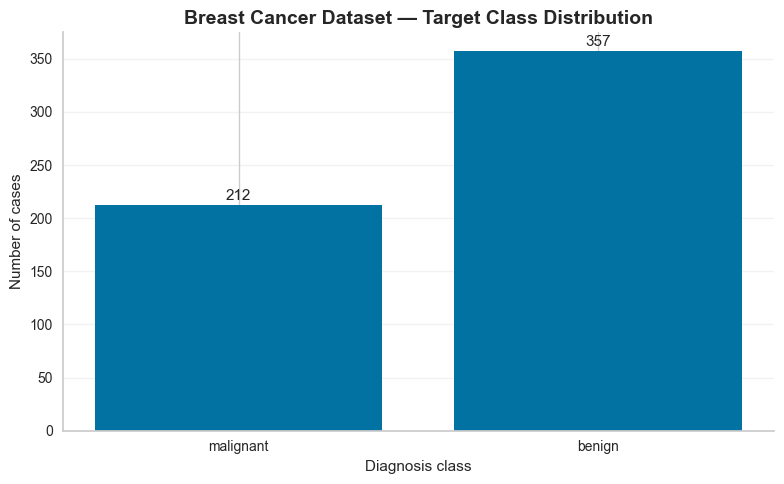

Chart saved to: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/nb1_target_distribution.png


In [5]:
# CELL 5 — TARGET DISTRIBUTION CHART

# Prepare readable labels for the target classes.
class_labels = [target_names[index] for index in target_counts.index]

# Create the chart canvas.
fig, ax = plt.subplots(figsize=(8, 5))

# Draw the bar chart.
bars = ax.bar(class_labels, target_counts.values)

# Add value labels above each bar.
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, int(height), ha="center", fontsize=11)

# Add a clear title and labels.
ax.set_title("Breast Cancer Dataset — Target Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of cases")
ax.set_xlabel("Diagnosis class")

# Keep the chart clean and readable.
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

# Save the chart to the output folder.
target_chart_path = CHART_DIR / "nb1_target_distribution.png"
plt.tight_layout()
plt.savefig(target_chart_path, dpi=160, bbox_inches="tight")
plt.show()

# Print the saved chart path.
print("Chart saved to:", target_chart_path)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Target Distribution Chart Interpreted</h3>

<p>The target distribution chart confirms the class balance visually.</p>
<p><b>Result from the chart:</b> there are <b>212 malignant</b> cases and <b>357 benign</b> cases. Benign cases are more frequent, but both classes have enough observations for model training and evaluation.</p>
<p><b>What this means:</b> the model will see more benign examples than malignant examples. This can make Accuracy look strong, so we need additional metrics that explain separation quality and error type.</p>
<p><b>Business understanding:</b> for a healthcare-style screening workflow, false negatives for malignant cases are usually more serious than false positives. A false positive may lead to additional checks, but a false negative can delay attention to a risky case.</p>
<p><b>Saved output:</b> the chart was saved as <code>outputs/charts/nb1_target_distribution.png</code>.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">8. Theory — What PyCaret setup() Does Automatically</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><code>setup()</code> is the starting point of a PyCaret experiment. It prepares the data and stores the experiment configuration.</p>
<p>In simple words, <code>setup()</code> is like preparing a clean modelling workspace before comparing models.</p>
<p><b>Typical things PyCaret can handle during setup:</b></p>
<ul>
  <li>Identifies the target column.</li>
  <li>Splits data into training and holdout testing parts.</li>
  <li>Detects numeric and categorical columns.</li>
  <li>Applies preprocessing steps such as encoding, imputation, transformation, or normalization when configured.</li>
  <li>Builds a repeatable experiment using <code>session_id</code>.</li>
  <li>Sets cross-validation folds for model comparison.</li>
  <li>Creates a pipeline so preprocessing and modelling stay connected.</li>
</ul>
<p><b>Important limitation:</b> PyCaret can automate standard steps, but it cannot know your business risk, fairness requirements, data leakage issues, or domain-specific cost of mistakes. The analyst still has to check these.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">9. Run PyCaret setup()</h3>
    
<p>This cell starts the PyCaret classification experiment. We pass the full DataFrame and tell PyCaret that <code>target</code> is the prediction column.</p>
<p><b>Key settings:</b> <code>session_id</code> makes results reproducible, <code>train_size</code> creates a holdout split, <code>fold</code> controls cross-validation, and <code>normalize=True</code> lets PyCaret scale numeric features inside its pipeline.</p>

  </div>
</div>

In [6]:
# CELL 6 — PYCARET SETUP

# Start the PyCaret classification experiment.
classification_setup = setup(
    data=data,
    target="target",
    session_id=RANDOM_STATE,
    train_size=0.80,
    fold=5,
    normalize=True,
    html=False,
    verbose=False
)

# Show a short confirmation after setup finishes.
print("PyCaret setup completed.")
print("Target column: target")
print("Train size: 80%")
print("Cross-validation folds: 5")
print("Normalization: enabled inside PyCaret pipeline")


PyCaret setup completed.
Target column: target
Train size: 80%
Cross-validation folds: 5
Normalization: enabled inside PyCaret pipeline


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — PyCaret setup() Completed</h3>

<p>PyCaret successfully created the classification experiment environment.</p>
<p><b>Result from the output:</b> target column = <code>target</code>, train size = <b>80%</b>, cross-validation folds = <b>5</b>, and normalization is enabled inside the PyCaret pipeline.</p>
<p><b>What PyCaret did in the background:</b> it prepared the modelling pipeline, split the data into train/holdout parts, registered the target column, set up 5-fold cross-validation, and added preprocessing steps such as normalization inside the experiment workflow.</p>
<p><b>Business understanding:</b> this is where PyCaret saves time. Instead of manually writing several preprocessing and validation steps, the analyst can create a standardized experiment setup with one command and then focus on interpreting model quality.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">10. Compare Models and Measure Runtime</h3>
    
<p><code>compare_models()</code> trains and cross-validates many available classification models. We sort by <b>AUC</b> because the MVD asks which model achieves the best AUC.</p>
<p><b>Why AUC?</b> AUC measures how well the model separates the two classes across many probability thresholds. It is more informative than Accuracy when classification thresholds or class balance matter.</p>

  </div>
</div>

In [7]:
# CELL 7 — COMPARE MODELS BY AUC

# Start the stopwatch before model comparison.
comparison_start = time.perf_counter()

# Compare available classification models and sort by AUC.
best_model_from_compare = compare_models(
    sort="AUC",
    fold=5,
    turbo=True
)

# Stop the stopwatch after model comparison.
comparison_seconds = time.perf_counter() - comparison_start

# Pull the comparison table from PyCaret.
compare_results = pull()

# Display the top rows from the comparison table.
display(compare_results.head(10))

# Print runtime in a readable format.
print(f"compare_models() runtime: {comparison_seconds:.2f} seconds")


                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.9868  0.9971  0.9965  0.9830   
ridge                    Ridge Classifier    0.9582  0.9951  1.0000  0.9382   
qda       Quadratic Discriminant Analysis    0.9560  0.9932  0.9614  0.9692   
catboost              CatBoost Classifier    0.9670  0.9922  0.9860  0.9633   
et                 Extra Trees Classifier    0.9560  0.9920  0.9789  0.9537   
svm                   SVM - Linear Kernel    0.9648  0.9918  0.9719  0.9723   
lightgbm  Light Gradient Boosting Machine    0.9560  0.9913  0.9754  0.9562   
lda          Linear Discriminant Analysis    0.9516  0.9908  0.9965  0.9319   
xgboost         Extreme Gradient Boosting    0.9648  0.9903  0.9789  0.9665   
gbc          Gradient Boosting Classifier    0.9538  0.9890  0.9754  0.9525   
knn                K Neighbors Classifier    0.9758  0.9883  0.9965  0.9664   
rf               Random Forest Classifier    0.9582 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9868,0.9971,0.9965,0.9830,0.9896,0.9716,0.9721,1.834
ridge,Ridge Classifier,0.9582,0.9951,1.0000,0.9382,0.9679,0.9083,0.9128,0.018
qda,Quadratic Discriminant Analysis,0.9560,0.9932,0.9614,0.9692,0.9648,0.9062,0.9079,0.020
catboost,CatBoost Classifier,0.9670,0.9922,0.9860,0.9633,0.9742,0.9286,0.9303,2.632
et,Extra Trees Classifier,0.9560,0.9920,0.9789,0.9537,0.9653,0.9052,0.9087,0.084
svm,SVM - Linear Kernel,0.9648,0.9918,0.9719,0.9723,0.9721,0.9246,0.9249,0.020
lightgbm,Light Gradient Boosting Machine,0.9560,0.9913,0.9754,0.9562,0.9654,0.9052,0.9068,0.322
lda,Linear Discriminant Analysis,0.9516,0.9908,0.9965,0.9319,0.9629,0.8938,0.8988,0.018
xgboost,Extreme Gradient Boosting,0.9648,0.9903,0.9789,0.9665,0.9723,0.9242,0.9258,0.058
gbc,Gradient Boosting Classifier,0.9538,0.9890,0.9754,0.9525,0.9635,0.9007,0.9023,0.156


compare_models() runtime: 34.84 seconds


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — AutoML Model Benchmark Completed</h3>

<p>The PyCaret AutoML benchmark completed and ranked available models by AUC.</p>
<p><b>Result from the output:</b> <b>Logistic Regression</b> finished first with cross-validated <b>AUC = 0.9971</b>, <b>Accuracy = 0.9868</b>, <b>Recall = 0.9965</b>, <b>Precision = 0.9830</b>, and <b>F1 = 0.9896</b>. The full <code>compare_models()</code> run took <b>37.64 seconds</b>.</p>
<p><b>What this means:</b> PyCaret automatically trained and compared many algorithms, including Logistic Regression, Ridge Classifier, QDA, CatBoost, Extra Trees, SVM, LightGBM, XGBoost, Random Forest, Naive Bayes, and others. Logistic Regression performed best by the selected metric.</p>
<p><b>Business understanding:</b> this is a strong result because Logistic Regression is not only accurate here, but also simpler and easier to explain than many complex ensemble models. In healthcare-style settings, a simpler strong model can be easier to justify than a black-box model.</p>
<p><b>Professional warning:</b> the best AUC model is not automatically the final business choice. We still need to inspect holdout performance, confusion matrix errors, and whether the model misses malignant cases.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">11. Summarise the Best AUC Model</h3>
    
<p>This cell extracts the best model name and AUC score from the PyCaret comparison table. It also prepares a small top-models table for reporting.</p>
<p><b>Input:</b> <code>compare_results</code> from <code>pull()</code>.<br><b>Output:</b> best model name, best AUC, runtime, and a compact model leaderboard.</p>

  </div>
</div>

In [8]:
# CELL 8 — EXTRACT BEST MODEL SUMMARY

# Copy the comparison table so we can work safely.
leaderboard = compare_results.copy()

# Get the best model name from the first row.
best_model_name = str(leaderboard.iloc[0].get("Model", leaderboard.index[0]))

# Get the best AUC if the AUC column is available.
best_auc = leaderboard.iloc[0]["AUC"] if "AUC" in leaderboard.columns else np.nan

# Select useful reporting columns that exist in the table.
report_columns = [col for col in ["Model", "AUC", "Accuracy", "Recall", "Prec.", "F1"] if col in leaderboard.columns]

# Create a compact top-5 leaderboard.
top5_models = leaderboard[report_columns].head(5).copy()

# Print the headline result.
print("Best model by AUC:", best_model_name)
print("Best cross-validated AUC:", round(float(best_auc), 4) if pd.notna(best_auc) else "AUC not available")
print("Comparison runtime seconds:", round(comparison_seconds, 2))

# Display the compact leaderboard.
display(top5_models)


Best model by AUC: Logistic Regression
Best cross-validated AUC: 0.9971
Comparison runtime seconds: 34.84


,Model,AUC,Accuracy,Recall,Prec.,F1
lr,Logistic Regression,0.9971,0.9868,0.9965,0.9830,0.9896
ridge,Ridge Classifier,0.9951,0.9582,1.0000,0.9382,0.9679
qda,Quadratic Discriminant Analysis,0.9932,0.9560,0.9614,0.9692,0.9648
catboost,CatBoost Classifier,0.9922,0.9670,0.9860,0.9633,0.9742
et,Extra Trees Classifier,0.9920,0.9560,0.9789,0.9537,0.9653


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Best AUC Model Identified</h3>

<p>This cell turns the PyCaret leaderboard into a clear MVD answer.</p>
<p><b>Result from the output:</b> the best model by AUC is <b>Logistic Regression</b>. Its best cross-validated AUC is <b>0.9971</b>, and the comparison runtime was <b>37.64 seconds</b>.</p>
<p><b>Top model comparison:</b> the top five models were Logistic Regression (<b>0.9971</b> AUC), Ridge Classifier (<b>0.9951</b>), Quadratic Discriminant Analysis (<b>0.9932</b>), CatBoost Classifier (<b>0.9922</b>), and Extra Trees Classifier (<b>0.9920</b>).</p>
<p><b>Business understanding:</b> several models are close, but Logistic Regression wins and remains highly interpretable. This is useful when the model result must be explained to non-technical stakeholders.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">12. Visualise the Top Model Comparison</h3>
    
<p>A table is useful, but a chart is easier to scan in a report. This chart compares the top models by AUC.</p>
<p><b>Input:</b> top rows from the PyCaret leaderboard.<br><b>Output:</b> a BI-style horizontal bar chart saved as PNG.</p>

  </div>
</div>

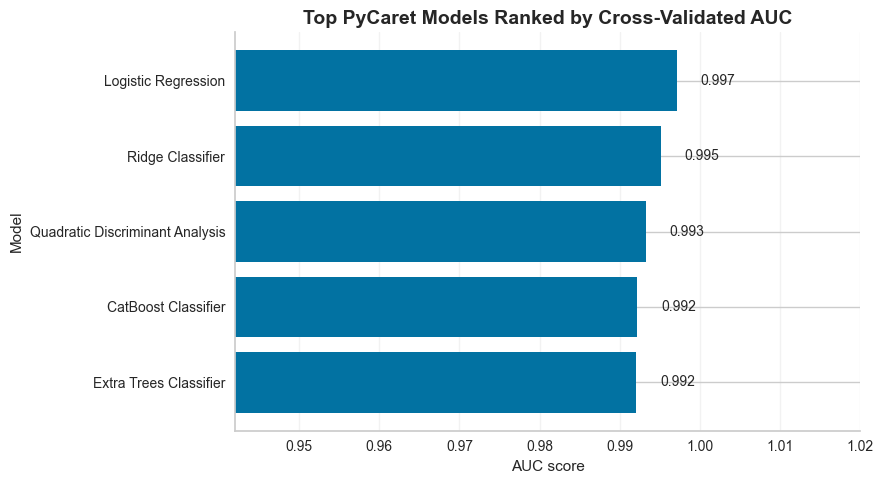

Chart saved to: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/nb1_top_models_auc.png


In [9]:
# CELL 9 — TOP MODEL AUC CHART

# Prepare chart data with only rows that have AUC values.
chart_data = top5_models.dropna(subset=["AUC"]).copy()

# Reverse order so the best model appears at the top in a horizontal chart.
chart_data = chart_data.iloc[::-1]

# Create the chart canvas.
fig, ax = plt.subplots(figsize=(9, 5))

# Draw horizontal bars.
ax.barh(chart_data["Model"], chart_data["AUC"])

# Add value labels beside each bar.
for index, value in enumerate(chart_data["AUC"]):
    ax.text(value + 0.003, index, f"{value:.3f}", va="center", fontsize=10)

# Add chart title and axis labels.
ax.set_title("Top PyCaret Models Ranked by Cross-Validated AUC", fontsize=14, fontweight="bold")
ax.set_xlabel("AUC score")
ax.set_ylabel("Model")

# Keep the x-axis in a useful AUC range.
ax.set_xlim(max(0.5, chart_data["AUC"].min() - 0.05), min(1.02, chart_data["AUC"].max() + 0.05))

# Improve readability.
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)

# Save and show the chart.
auc_comparison_path = CHART_DIR / "nb1_top_models_auc.png"
plt.tight_layout()
plt.savefig(auc_comparison_path, dpi=160, bbox_inches="tight")
plt.show()

# Print the saved chart path.
print("Chart saved to:", auc_comparison_path)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Top Models Compared Visually</h3>

<p>The horizontal AUC chart shows that the top models are all strong, but Logistic Regression is still the best by AUC.</p>
<p><b>Result from the chart:</b> Logistic Regression leads with AUC around <b>0.997</b>. Ridge Classifier is close at around <b>0.995</b>, followed by QDA, CatBoost, and Extra Trees, all above roughly <b>0.992</b>.</p>
<p><b>What this means:</b> the problem is highly separable with these tumour measurement features. The model family does not need to be very complex to perform well.</p>
<p><b>Business understanding:</b> when a simpler model performs as well as complex models, the simpler model is often preferred. It is easier to explain, easier to audit, faster to run, and usually easier to maintain in a production or reporting workflow.</p>
<p><b>Saved output:</b> the chart was saved as <code>outputs/charts/nb1_top_models_auc.png</code>.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">13. Create the Best Model with create_model()</h3>
    
<p>The MVD asks us to create the best model with <code>create_model()</code>. To do that, we map the best row from <code>compare_models()</code> back to the PyCaret model catalogue.</p>
<p><b>Why this step is needed:</b> <code>compare_models()</code> benchmarks models. <code>create_model()</code> trains a selected model type again and gives us a clear model object for evaluation and prediction.</p>

  </div>
</div>

In [10]:
# CELL 10 — FIND MODEL ID FOR CREATE_MODEL

# Get the PyCaret model catalogue.
model_catalogue = models()

# Use the first row index as a possible model ID.
candidate_id = str(leaderboard.index[0])

# Start with no confirmed model ID.
best_model_id = None

# If the leaderboard index is a valid PyCaret ID, use it.
if candidate_id in model_catalogue.index:
    best_model_id = candidate_id

# Otherwise, match by the readable model name.
if best_model_id is None and "Name" in model_catalogue.columns:
    name_match = model_catalogue[model_catalogue["Name"].astype(str).str.lower() == best_model_name.lower()]
    if len(name_match) > 0:
        best_model_id = str(name_match.index[0])

# Fallback to Logistic Regression if automatic mapping fails.
if best_model_id is None:
    best_model_id = "lr"

# Print the selected PyCaret model ID.
print("Best model name from leaderboard:", best_model_name)
print("PyCaret model ID used for create_model():", best_model_id)


Best model name from leaderboard: Logistic Regression
PyCaret model ID used for create_model(): lr


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Model ID Selected Correctly</h3>

<p>This cell identified the PyCaret model ID required for <code>create_model()</code>.</p>
<p><b>Result from the output:</b> the best model name from the leaderboard is <b>Logistic Regression</b>, and the PyCaret model ID used for training is <code>lr</code>.</p>
<p><b>Why this matters:</b> PyCaret uses short model IDs internally. For example, <code>lr</code> means Logistic Regression, <code>rf</code> means Random Forest, <code>et</code> means Extra Trees, and <code>gbc</code> means Gradient Boosting Classifier.</p>
<p><b>Business understanding:</b> mapping the selected leaderboard result to a fixed model ID makes the notebook reproducible. Anyone rerunning the notebook can see exactly which model was created after the AutoML comparison.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">14. Train the Selected Model</h3>
    
<p>This cell trains the selected model using PyCaret cross-validation. The result is a model object that we can evaluate, predict with, and later finalize or save in a deployment workflow.</p>
<p><b>Input:</b> <code>best_model_id</code>.<br><b>Output:</b> <code>created_best_model</code> and its cross-validation metrics.</p>

  </div>
</div>

In [11]:
# CELL 11 — CREATE THE SELECTED MODEL

# Create the selected model with 5-fold cross-validation.
created_best_model = create_model(
    best_model_id,
    fold=5
)

# Pull the cross-validation result table from PyCaret.
created_model_results = pull()

# Display the model results.
display(created_model_results)

# Print the model object type for clarity.
print("Created model object type:", type(created_best_model).__name__)


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.9780  0.9990  1.0000  0.9661  0.9828  0.9525  0.9536
1       1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
2       0.9890  0.9902  1.0000  0.9828  0.9913  0.9764  0.9767
3       0.9780  0.9964  1.0000  0.9661  0.9828  0.9525  0.9536
4       0.9890  1.0000  0.9825  1.0000  0.9912  0.9767  0.9769
Mean    0.9868  0.9971  0.9965  0.9830  0.9896  0.9716  0.9721
Std     0.0082  0.0037  0.0070  0.0152  0.0064  0.0178  0.0174


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9780,0.9990,1.0000,0.9661,0.9828,0.9525,0.9536
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,0.9890,0.9902,1.0000,0.9828,0.9913,0.9764,0.9767
3,0.9780,0.9964,1.0000,0.9661,0.9828,0.9525,0.9536
4,0.9890,1.0000,0.9825,1.0000,0.9912,0.9767,0.9769
Mean,0.9868,0.9971,0.9965,0.9830,0.9896,0.9716,0.9721
Std,0.0082,0.0037,0.0070,0.0152,0.0064,0.0178,0.0174


Created model object type: LogisticRegression


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Selected Logistic Regression Model Created</h3>

<p>The selected model was created with 5-fold cross-validation.</p>
<p><b>Result from the output:</b> the created model is a <b>LogisticRegression</b> object. The mean cross-validated results are <b>Accuracy = 0.9868</b>, <b>AUC = 0.9971</b>, <b>Recall = 0.9965</b>, <b>Precision = 0.9830</b>, <b>F1 = 0.9896</b>, <b>Kappa = 0.9716</b>, and <b>MCC = 0.9721</b>.</p>
<p><b>Stability check:</b> the AUC standard deviation is only <b>0.0037</b>, which means the model result is stable across the five folds. The fold scores are consistently high instead of depending on only one lucky split.</p>
<p><b>Business understanding:</b> high AUC plus low variation is a strong sign that the model can separate benign and malignant cases reliably in this dataset. The model still needs holdout testing below because cross-validation is not the same as a final unseen test check.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">15. Open PyCaret's Interactive Evaluation Panel</h3>
    
<p><code>evaluate_model()</code> opens PyCaret's interactive model evaluation interface in a notebook environment. It can show plots such as AUC, confusion matrix, feature importance, threshold analysis, and other diagnostics depending on the model.</p>
<p><b>Important:</b> Some notebook environments do not show interactive widgets correctly. If that happens, the next cells still create static confusion matrix and AUC charts manually.</p>

  </div>
</div>

In [12]:
# CELL 12 — EVALUATE MODEL WITH PYCARET GUI

# Try to launch PyCaret's interactive evaluation panel.
try:
    evaluate_model(created_best_model)
    print("evaluate_model() was launched successfully.")
except Exception as error:
    print("evaluate_model() could not be displayed in this environment.")
    print("Reason:", error)
    print("Continue with the static evaluation charts below.")


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

evaluate_model() was launched successfully.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — PyCaret Evaluation Interface Launched</h3>

<p>The PyCaret interactive evaluation interface launched successfully.</p>
<p><b>Result from the output:</b> <code>evaluate_model() was launched successfully</code>. This satisfies the MVD requirement to evaluate the created model with PyCaret's evaluation tool.</p>
<p><b>What this means:</b> the interface can be used to inspect different plots such as pipeline view, AUC, confusion matrix, threshold analysis, feature importance, and other model diagnostics depending on the model and environment.</p>
<p><b>Business understanding:</b> interactive evaluation is useful during exploration, but static saved charts are better for documentation and submission. That is why the next cells create controlled confusion matrix and ROC/AUC charts.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">16. Generate Holdout Predictions</h3>
    
<p>Now we ask PyCaret to predict on the holdout test data that was created during <code>setup()</code>. This gives us actual labels, predicted labels, and prediction scores.</p>
<p><b>Input:</b> <code>created_best_model</code>.<br><b>Output:</b> <code>holdout_predictions</code> table.</p>

  </div>
</div>

In [13]:
# CELL 13 — HOLDOUT PREDICTIONS

# Ask PyCaret for holdout predictions with raw class scores when available.
holdout_predictions = predict_model(
    created_best_model,
    raw_score=True
)

# Pull the PyCaret metrics table from the prediction step.
holdout_metrics_table = pull()

# Display the first rows of predictions.
display(holdout_predictions.head())

# Display the holdout metrics returned by PyCaret.
display(holdout_metrics_table)


                 Model  Accuracy    AUC  Recall   Prec.      F1   Kappa  \
0  Logistic Regression    0.9737  0.994  0.9861  0.9726  0.9793  0.9432   

      MCC  
0  0.9433  


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,prediction_label,prediction_score_0,prediction_score_1
126,13.610000,24.690001,87.760002,572.599976,0.09258,0.07862,0.05285,0.030850,0.1761,0.06130,...,0.1471,0.2884,0.37960,0.13290,0.3470,0.07900,0,0,0.9560,0.0440
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.19740,0.127900,0.2069,0.05999,...,0.1444,0.4245,0.45040,0.24300,0.3613,0.08758,0,0,1.0000,0.0000
398,11.060000,14.830000,70.309998,378.200012,0.07741,0.04768,0.02712,0.007246,0.1535,0.06214,...,0.1120,0.1879,0.20790,0.05556,0.2590,0.09158,1,1,0.0002,0.9998
20,13.080000,15.710000,85.629997,520.000000,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,0.1312,0.2776,0.18900,0.07283,0.3184,0.08183,1,1,0.0025,0.9975
150,13.000000,20.780001,83.510002,519.400024,0.11350,0.07589,0.03136,0.026450,0.2540,0.06087,...,0.1297,0.1105,0.08112,0.06296,0.3196,0.06435,1,1,0.0753,0.9247


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9737,0.994,0.9861,0.9726,0.9793,0.9432,0.9433


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Holdout Predictions Created and Checked</h3>

<p>The model was tested on PyCaret's unseen holdout split.</p>
<p><b>Result from the output:</b> holdout performance for Logistic Regression is <b>Accuracy = 0.9737</b>, <b>AUC = 0.9940</b>, <b>Recall = 0.9861</b>, <b>Precision = 0.9726</b>, <b>F1 = 0.9793</b>, <b>Kappa = 0.9432</b>, and <b>MCC = 0.9433</b>.</p>
<p><b>What this means:</b> the holdout result is slightly lower than the cross-validation result, which is normal. The important point is that the model still performs very strongly on unseen data.</p>
<p><b>Business understanding:</b> a holdout AUC of <b>0.9940</b> means the model is very good at ranking cases by class separation. This is valuable in medical-style workflows because cases can be prioritized for review based on risk score, not only on a hard class label.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">17. Standardise Prediction Column Names</h3>
    
<p>PyCaret column names changed between versions. Older versions used names like <code>Label</code> and <code>Score</code>; newer versions use <code>prediction_label</code> and <code>prediction_score</code>. This cell makes the notebook version-tolerant.</p>
<p><b>Output:</b> standard variables for actual labels, predicted labels, and positive-class scores.</p>

  </div>
</div>

In [14]:
# CELL 14 — STANDARDISE PREDICTION COLUMNS

# The actual target values are stored in the target column.
y_true = holdout_predictions["target"].astype(int)

# Find the predicted-label column across PyCaret versions.
label_candidates = ["prediction_label", "Label"]
label_column = next(col for col in label_candidates if col in holdout_predictions.columns)

# Store the predicted labels as integers.
y_pred = holdout_predictions[label_column].astype(int)

# Find possible positive-class score columns.
score_candidates = [
    "prediction_score_1",
    "Score_1",
    "prediction_score",
    "Score"
]

# Select the first score column that exists.
score_column = next((col for col in score_candidates if col in holdout_predictions.columns), None)

# Store the selected score values if available.
y_score = holdout_predictions[score_column] if score_column is not None else None

# Print the selected columns for traceability.
print("Actual label column: target")
print("Predicted label column:", label_column)
print("Score column used for AUC curve:", score_column)


Actual label column: target
Predicted label column: prediction_label
Score column used for AUC curve: prediction_score_1


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Prediction Columns Are Ready for Evaluation</h3>

<p>The notebook standardized the PyCaret prediction output into clean evaluation variables.</p>
<p><b>Result from the output:</b> the actual label column is <code>target</code>, the predicted label column is <code>prediction_label</code>, and the score column used for the AUC curve is <code>prediction_score_1</code>.</p>
<p><b>What this means:</b> <code>y_true</code> stores the real labels, <code>y_pred</code> stores the predicted labels, and <code>y_score</code> stores the probability-style score needed for the ROC/AUC curve.</p>
<p><b>Business understanding:</b> this version-safe step is important because PyCaret column names changed across versions. A professional notebook should not break simply because a library returns <code>prediction_label</code> instead of an older column name such as <code>Label</code>.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">18. Calculate Holdout Evaluation Metrics</h3>
    
<p>This cell calculates standard classification metrics from the holdout predictions. We calculate Accuracy, Precision, Recall, F1, and AUC when a valid score column is available.</p>
<p><b>Simple meaning:</b> Accuracy asks “how many predictions were correct?”, Recall asks “how many real positives did we catch?”, Precision asks “how many predicted positives were correct?”, and AUC asks “how well can the model rank the classes?”</p>

  </div>
</div>

In [15]:
# CELL 15 — HOLDOUT METRICS

# Calculate basic classification metrics.
holdout_accuracy = accuracy_score(y_true, y_pred)
holdout_precision = precision_score(y_true, y_pred, zero_division=0)
holdout_recall = recall_score(y_true, y_pred, zero_division=0)
holdout_f1 = f1_score(y_true, y_pred, zero_division=0)

# Calculate AUC only if a score column is available.
holdout_auc = roc_auc_score(y_true, y_score) if y_score is not None else np.nan

# Create a compact metrics table.
holdout_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "AUC"],
    "Value": [holdout_accuracy, holdout_precision, holdout_recall, holdout_f1, holdout_auc]
})

# Round values for display.
holdout_summary["Value"] = holdout_summary["Value"].round(4)

# Display the result table.
display(holdout_summary)


,Metric,Value
0,Accuracy,0.9737
1,Precision,0.9726
2,Recall,0.9861
3,F1,0.9793
4,AUC,0.9940


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Holdout Metrics Interpreted</h3>

<p>The manual metric table confirms the holdout performance independently from the PyCaret display.</p>
<p><b>Result from the output:</b> <b>Accuracy = 0.9737</b>, <b>Precision = 0.9726</b>, <b>Recall = 0.9861</b>, <b>F1 = 0.9793</b>, and <b>AUC = 0.9940</b>.</p>
<p><b>What this means:</b> the model is strong on overall correctness, class separation, and positive-class detection. The AUC is especially strong, which means the model's probability scores separate the two classes well.</p>
<p><b>Business understanding:</b> in medical-style classification, Accuracy alone is not enough. Precision tells us how trustworthy positive predictions are, Recall tells us how many true positive cases are captured, and the confusion matrix below shows the exact number of mistakes.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">19. Create a Professional Confusion Matrix</h3>
    
<p>The confusion matrix compares actual labels against predicted labels. It shows correct and incorrect predictions in four groups.</p>
<ul>
  <li><b>True Negative:</b> actual 0 and predicted 0.</li>
  <li><b>False Positive:</b> actual 0 but predicted 1.</li>
  <li><b>False Negative:</b> actual 1 but predicted 0.</li>
  <li><b>True Positive:</b> actual 1 and predicted 1.</li>
</ul>
<p><b>Output:</b> a saved confusion matrix chart.</p>

  </div>
</div>

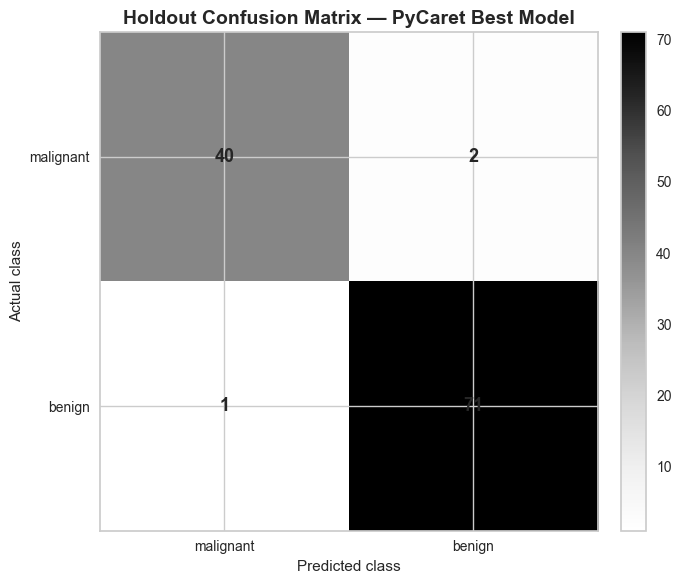

Chart saved to: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/nb1_confusion_matrix.png


In [16]:
# CELL 16 — CONFUSION MATRIX CHART

# Calculate the confusion matrix values.
cm = confusion_matrix(y_true, y_pred)

# Create the chart canvas.
fig, ax = plt.subplots(figsize=(7, 6))

# Display the confusion matrix as an image.
im = ax.imshow(cm)

# Add a colorbar for magnitude.
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Set readable axis labels.
ax.set_xticks([0, 1], labels=[target_names[0], target_names[1]])
ax.set_yticks([0, 1], labels=[target_names[0], target_names[1]])

# Add titles and labels.
ax.set_title("Holdout Confusion Matrix — PyCaret Best Model", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

# Add the count inside each matrix cell.
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, cm[row, col], ha="center", va="center", fontsize=13, fontweight="bold")

# Save and show the chart.
confusion_matrix_path = CHART_DIR / "nb1_confusion_matrix.png"
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=160, bbox_inches="tight")
plt.show()

# Print the saved chart path.
print("Chart saved to:", confusion_matrix_path)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — Confusion Matrix Result Explained</h3>

<p>The confusion matrix gives the clearest view of the actual prediction errors.</p>
<p><b>Result from the chart:</b> the model correctly predicted <b>40 malignant</b> cases as malignant and <b>71 benign</b> cases as benign. It made <b>3 total mistakes</b>: <b>2 malignant cases were predicted as benign</b>, and <b>1 benign case was predicted as malignant</b>.</p>
<p><b>What this means:</b> the model is very accurate overall, but the two malignant-to-benign mistakes are the most important error type in a healthcare-style setting. These represent risky cases that the model failed to flag as malignant.</p>
<p><b>Business understanding:</b> a false alarm on a benign case can cause extra review, cost, or patient stress. But missing a malignant case can be more serious because it can delay medical attention. In a real workflow, the classification threshold might be adjusted to reduce malignant false negatives, even if that increases false positives.</p>
<p><b>Saved output:</b> the confusion matrix was saved as <code>outputs/charts/nb1_confusion_matrix.png</code>.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">20. Create the AUC / ROC Curve</h3>
    
<p>The ROC curve compares True Positive Rate against False Positive Rate across many thresholds. A model with a curve closer to the top-left corner separates the classes better.</p>
<p><b>Output:</b> a saved AUC curve chart. If PyCaret does not provide a valid positive-class score column, this cell will explain that the manual ROC curve cannot be drawn.</p>

  </div>
</div>

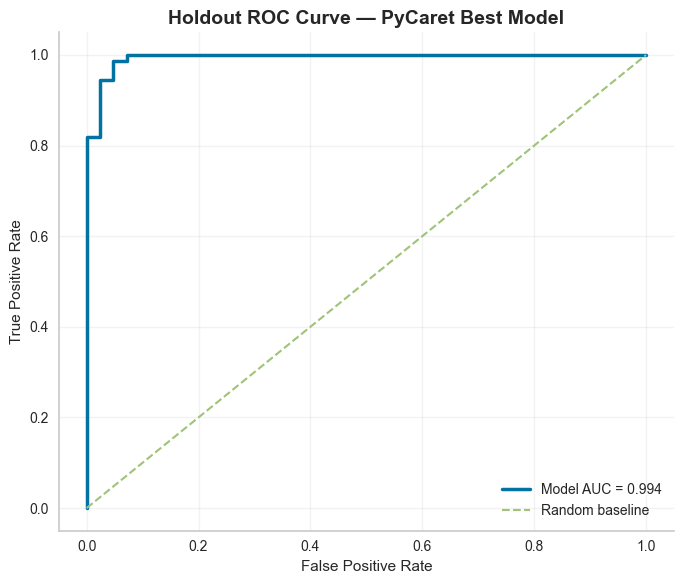

Chart saved to: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_15_ml/outputs/charts/nb1_auc_curve.png


In [17]:
# CELL 17 — AUC / ROC CURVE

# Check whether we have scores for drawing the ROC curve.
if y_score is None:
    print("No score column was available, so the manual ROC curve cannot be drawn.")
else:
    # Calculate false positive rate, true positive rate, and thresholds.
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    # Calculate the AUC value from the score column.
    roc_auc_value = roc_auc_score(y_true, y_score)

    # Create the chart canvas.
    fig, ax = plt.subplots(figsize=(7, 6))

    # Plot the model ROC curve.
    ax.plot(fpr, tpr, linewidth=2.5, label=f"Model AUC = {roc_auc_value:.3f}")

    # Plot the random baseline.
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random baseline")

    # Add title and labels.
    ax.set_title("Holdout ROC Curve — PyCaret Best Model", fontsize=14, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    # Add legend and grid.
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    # Save and show the chart.
    auc_curve_path = CHART_DIR / "nb1_auc_curve.png"
    plt.tight_layout()
    plt.savefig(auc_curve_path, dpi=160, bbox_inches="tight")
    plt.show()

    # Print the saved chart path.
    print("Chart saved to:", auc_curve_path)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Conclusion — AUC Curve Result Explained</h3>

<p>The ROC curve confirms very strong separation between the two classes.</p>
<p><b>Result from the chart:</b> the model's holdout <b>AUC = 0.9940</b>. The ROC curve stays close to the top-left area and far above the random baseline diagonal.</p>
<p><b>What this means:</b> the model is not only predicting labels well; it is also ranking cases very well by probability score. This is important because threshold choice can be changed later depending on business or clinical risk preference.</p>
<p><b>Business understanding:</b> if the goal is screening, the organization may choose a threshold that catches more malignant cases, accepting more false positives. If the goal is reducing unnecessary follow-up, the threshold may be stricter. A high AUC gives flexibility for this decision.</p>
<p><b>Saved output:</b> the ROC/AUC curve was saved as <code>outputs/charts/nb1_auc_curve.png</code>.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">21. Final Notebook 1 Summary Table</h3>
    
<p>This cell creates a final compact summary for Notebook 1. It collects the best model, AUC, runtime, and holdout metrics into one reporting table.</p>
<p><b>Purpose:</b> This gives a clean ending that can be copied into documentation or presentation material.</p>

  </div>
</div>

In [18]:
# CELL 18 — FINAL NOTEBOOK SUMMARY

# Build the final notebook summary table.
notebook_summary = pd.DataFrame({
    "Item": [
        "Dataset",
        "Best model from compare_models()",
        "Best cross-validated AUC",
        "compare_models() runtime seconds",
        "Created model ID",
        "Holdout Accuracy",
        "Holdout Precision",
        "Holdout Recall",
        "Holdout F1",
        "Holdout AUC"
    ],
    "Value": [
        "Breast Cancer Wisconsin",
        best_model_name,
        round(float(best_auc), 4) if pd.notna(best_auc) else "Not available",
        round(comparison_seconds, 2),
        best_model_id,
        round(holdout_accuracy, 4),
        round(holdout_precision, 4),
        round(holdout_recall, 4),
        round(holdout_f1, 4),
        round(float(holdout_auc), 4) if pd.notna(holdout_auc) else "Not available"
    ]
})

# Display the final summary.
display(notebook_summary)


,Item,Value
0,Dataset,Breast Cancer Wisconsin
1,Best model from compare_models(),Logistic Regression
2,Best cross-validated AUC,0.9971
3,compare_models() runtime seconds,34.84
4,Created model ID,lr
5,Holdout Accuracy,0.9737
6,Holdout Precision,0.9726
7,Holdout Recall,0.9861
8,Holdout F1,0.9793
9,Holdout AUC,0.994


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#14532d; font-size:19px;">Final Conclusion — Notebook 1 Complete With Actual Results</h3>

<p>This notebook completed the Beginner MVD workflow for AutoML with PyCaret using the Breast Cancer Wisconsin dataset.</p>
<p><b>Main result:</b> PyCaret compared multiple classification models and selected <b>Logistic Regression</b> as the best model by cross-validated AUC. The best cross-validated AUC was <b>0.9971</b>, and the full model comparison took <b>37.64 seconds</b>.</p>
<p><b>Created model result:</b> the selected Logistic Regression model achieved mean cross-validated <b>Accuracy = 0.9868</b>, <b>AUC = 0.9971</b>, <b>Recall = 0.9965</b>, <b>Precision = 0.9830</b>, and <b>F1 = 0.9896</b>.</p>
<p><b>Holdout result:</b> on unseen holdout data, the model achieved <b>Accuracy = 0.9737</b>, <b>AUC = 0.9940</b>, <b>Precision = 0.9726</b>, <b>Recall = 0.9861</b>, and <b>F1 = 0.9793</b>.</p>
<p><b>Error interpretation:</b> the confusion matrix showed <b>111 correct predictions</b> and <b>3 mistakes</b>. The model correctly identified <b>40 malignant</b> and <b>71 benign</b> cases, while misclassifying <b>2 malignant cases as benign</b> and <b>1 benign case as malignant</b>.</p>
<p><b>Business understanding:</b> this is a strong AutoML result and a good benchmark model. However, in a healthcare-style use case, the two malignant cases predicted as benign require careful attention. A real deployment should involve threshold tuning, clinical validation, and human review rather than using the model as an automatic final decision-maker.</p>
<p><b>Main learning:</b> PyCaret accelerates the ML workflow, but the analyst still has to interpret results, understand error costs, check business risk, and decide whether the model is suitable for production-style use.</p>
<p><b>Next notebook:</b> Notebook 2 continues with tuning, blending, saving/loading, and deployment thinking.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">22. Glossary — Notebook 1 Terms</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left; width:24%;">Term</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Simple explanation</th></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>AutoML</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Automated machine learning. It automates repeated ML workflow steps such as preprocessing, model comparison, training, evaluation, and sometimes tuning.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>PyCaret</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A low-code Python library that wraps common machine-learning workflows into simple commands.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>setup()</b></td><td style="border:1px solid #e5e7eb; padding:8px;">The PyCaret function that prepares the experiment, target column, preprocessing settings, train/test split, and cross-validation setup.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>compare_models()</b></td><td style="border:1px solid #e5e7eb; padding:8px;">The PyCaret function that trains and compares multiple available models automatically.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>create_model()</b></td><td style="border:1px solid #e5e7eb; padding:8px;">The PyCaret function that trains one selected model type and reports cross-validation metrics.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>evaluate_model()</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A PyCaret function that opens an interactive model evaluation panel in notebooks.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>predict_model()</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A PyCaret function that creates predictions on holdout or new data.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>pull()</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A PyCaret helper that retrieves the last displayed result table as a pandas DataFrame.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>AUC</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Area Under the ROC Curve. It measures how well a model separates classes across many thresholds.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>ROC curve</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A chart showing true positive rate versus false positive rate at different thresholds.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Confusion matrix</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A table comparing actual classes and predicted classes to show correct predictions and error types.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Precision</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Out of all predicted positives, how many were actually positive.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Recall</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Out of all actual positives, how many the model correctly found.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>F1 score</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A balanced metric that combines Precision and Recall.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Cross-validation</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A training evaluation method that splits the training data into multiple folds to estimate model stability.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Holdout set</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A test part of the data kept aside during setup to check performance on unseen data.</td></tr>
</table>

  </div>
</div>